<a href="https://colab.research.google.com/github/madhumithamadasamy/DataAnalytics-Using-Python-Project/blob/main/Final_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# E-Commerce Sales analysis

In [2]:
from google.colab import files

uploaded = files.upload()


Saving sales_data_250_records.csv to sales_data_250_records.csv


In [3]:
import pandas as pd

# Load the dataset
df = pd.read_csv("sales_data_250_records.csv")

# Display first 5 rows
df.head()

,Order_ID,Order_Date,Customer_Name,Region,State,Category,Product,Quantity,Unit_Price,Discount,Sales,Profit,Payment_Mode
0,1001,2025-11-24,Meena,South,Karnataka,Electronics,Headphones,4,1800,5,6840.0,1439.62,UPI
1,1002,2025-10-30,Nisha,South,Tamil Nadu,Electronics,Mobile,4,22000,5,83600.0,14697.16,UPI
2,1003,2025-10-15,Suresh,West,Maharashtra,Clothing,Shirt,10,900,10,8100.0,1793.46,UPI
3,1004,2025-03-23,Nisha,East,Assam,Electronics,Tablet,4,18000,10,64800.0,7473.48,Net Banking
4,1005,2025-02-19,Deepa,East,Assam,Grocery,Oil,1,180,15,153.0,27.61,Net Banking


In [4]:
# Number of rows and columns
print("Shape:", df.shape)

# Dataset information
df.info()

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Check duplicate rows
print("\nDuplicate Rows:", df.duplicated().sum())

Shape: (252, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 252 entries, 0 to 251
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order_ID       252 non-null    int64  
 1   Order_Date     252 non-null    object 
 2   Customer_Name  251 non-null    object 
 3   Region         252 non-null    object 
 4   State          251 non-null    object 
 5   Category       252 non-null    object 
 6   Product        252 non-null    object 
 7   Quantity       252 non-null    int64  
 8   Unit_Price     252 non-null    int64  
 9   Discount       252 non-null    int64  
 10  Sales          252 non-null    float64
 11  Profit         252 non-null    float64
 12  Payment_Mode   252 non-null    object 
dtypes: float64(2), int64(4), object(7)
memory usage: 25.7+ KB

Missing Values:
Order_ID         0
Order_Date       0
Customer_Name    1
Region           0
State            1
Category         0
Product          0
Quant

In [5]:
# Remove duplicate rows
df.drop_duplicates(inplace=True)

# Fill missing values
df["Customer_Name"].fillna("Unknown", inplace=True)
df["State"].fillna("Unknown", inplace=True)

# Verify cleaning
print("\nMissing Values After Cleaning:")
print(df.isnull().sum())

print("\nDataset Shape After Cleaning:", df.shape)


Missing Values After Cleaning:
Order_ID         0
Order_Date       0
Customer_Name    0
Region           0
State            0
Category         0
Product          0
Quantity         0
Unit_Price       0
Discount         0
Sales            0
Profit           0
Payment_Mode     0
dtype: int64

Dataset Shape After Cleaning: (250, 13)


/tmp/ipykernel_1419/3364469791.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Customer_Name"].fillna("Unknown", inplace=True)
/tmp/ipykernel_1419/3364469791.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', t

In [6]:
df.head(10)

,Order_ID,Order_Date,Customer_Name,Region,State,Category,Product,Quantity,Unit_Price,Discount,Sales,Profit,Payment_Mode
0,1001,2025-11-24,Meena,South,Karnataka,Electronics,Headphones,4,1800,5,6840.0,1439.62,UPI
1,1002,2025-10-30,Nisha,South,Tamil Nadu,Electronics,Mobile,4,22000,5,83600.0,14697.16,UPI
2,1003,2025-10-15,Suresh,West,Maharashtra,Clothing,Shirt,10,900,10,8100.0,1793.46,UPI
3,1004,2025-03-23,Nisha,East,Assam,Electronics,Tablet,4,18000,10,64800.0,7473.48,Net Banking
4,1005,2025-02-19,Deepa,East,Assam,Grocery,Oil,1,180,15,153.0,27.61,Net Banking
5,1006,2025-02-10,Pooja,East,Assam,Furniture,Table,4,8500,0,34000.0,3633.70,Card
6,1007,2025-05-29,Arun,North,Delhi,Clothing,Jeans,5,1500,15,6375.0,1245.37,Cash
7,1008,2025-03-25,Deepa,East,Odisha,Furniture,Sofa,5,25000,0,125000.0,23921.21,Card
8,1009,2025-10-01,Anitha,North,Punjab,Clothing,Jeans,5,1500,5,7125.0,1444.18,UPI
9,1010,2025-04-28,Priya,East,Bihar,Electronics,Smart Watch,2,4500,5,8550.0,2026.10,Cash


In [7]:
# Total Sales
print("Total Sales:", df["Sales"].sum())

# Region-wise Sales
print("\nRegion-wise Sales:")
print(df.groupby("Region")["Sales"].sum())

# Category-wise Sales
print("\nCategory-wise Sales:")
print(df.groupby("Category")["Sales"].sum())

# Top 5 Selling Products
print("\nTop 5 Products:")
print(df.groupby("Product")["Sales"].sum().sort_values(ascending=False).head())

Total Sales: 12011009.0

Region-wise Sales:
Region
East     2967014.0
North    2681404.5
South    4332323.5
West     2030267.0
Name: Sales, dtype: float64

Category-wise Sales:
Category
Clothing        272355.0
Electronics    7663685.0
Furniture      4050075.0
Grocery          24894.0
Name: Sales, dtype: float64

Top 5 Products:
Product
Laptop    3063500.0
Mobile    2577300.0
Sofa      2571250.0
Tablet    1350000.0
Table     1181500.0
Name: Sales, dtype: float64


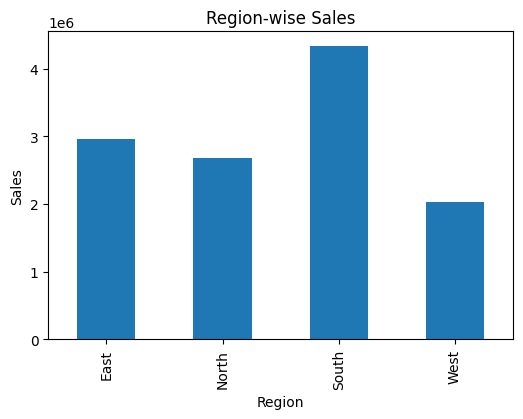

In [8]:
import matplotlib.pyplot as plt

# Region-wise Sales Chart
region_sales = df.groupby("Region")["Sales"].sum()

plt.figure(figsize=(6,4))
region_sales.plot(kind="bar")
plt.title("Region-wise Sales")
plt.xlabel("Region")
plt.ylabel("Sales")
plt.show()

In [9]:
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 250 entries, 0 to 249
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order_ID       250 non-null    int64  
 1   Order_Date     250 non-null    object 
 2   Customer_Name  250 non-null    object 
 3   Region         250 non-null    object 
 4   State          250 non-null    object 
 5   Category       250 non-null    object 
 6   Product        250 non-null    object 
 7   Quantity       250 non-null    int64  
 8   Unit_Price     250 non-null    int64  
 9   Discount       250 non-null    int64  
 10  Sales          250 non-null    float64
 11  Profit         250 non-null    float64
 12  Payment_Mode   250 non-null    object 
dtypes: float64(2), int64(4), object(7)
memory usage: 35.4+ KB


,Order_ID,Quantity,Unit_Price,Discount,Sales,Profit
count,250.000000,250.00000,250.000000,250.000000,250.000000,250.000000
mean,1125.500000,5.53600,8871.660000,8.180000,48044.036000,8627.496560
std,72.312977,2.89035,12616.560321,5.523553,81163.210432,15420.099164
min,1001.000000,1.00000,45.000000,0.000000,40.500000,6.060000
25%,1063.250000,3.00000,900.000000,5.000000,1991.250000,374.450000
50%,1125.500000,5.00000,3500.000000,10.000000,12420.000000,2008.995000
75%,1187.750000,8.00000,18000.000000,15.000000,60775.000000,10570.680000
max,1250.000000,10.00000,55000.000000,15.000000,495000.000000,100899.260000


In [10]:
# Check missing values
print(df.isnull().sum())

# Check duplicate rows
print(df.duplicated().sum())

# Remove duplicate rows
df = df.drop_duplicates()

# Fill missing values
df["Customer_Name"] = df["Customer_Name"].fillna("Unknown")
df["State"] = df["State"].fillna("Unknown")

Order_ID         0
Order_Date       0
Customer_Name    0
Region           0
State            0
Category         0
Product          0
Quantity         0
Unit_Price       0
Discount         0
Sales            0
Profit           0
Payment_Mode     0
dtype: int64
0


In [11]:
# Total Sales
print("Total Sales:", df["Sales"].sum())

Total Sales: 12011009.0


In [12]:
#Region-wise Sales
print(df.groupby("Region")["Sales"].sum())

Region
East     2967014.0
North    2681404.5
South    4332323.5
West     2030267.0
Name: Sales, dtype: float64


In [13]:
#Category-wise Sales
print(df.groupby("Category")["Sales"].sum())

Category
Clothing        272355.0
Electronics    7663685.0
Furniture      4050075.0
Grocery          24894.0
Name: Sales, dtype: float64


In [14]:
#Top 10 Products
print(df.groupby("Product")["Sales"].sum().sort_values(ascending=False).head(10))

Product
Laptop         3063500.0
Mobile         2577300.0
Sofa           2571250.0
Tablet         1350000.0
Table          1181500.0
Smart Watch     482625.0
Chair           297325.0
Headphones      190260.0
Jeans           138450.0
Shirt            93690.0
Name: Sales, dtype: float64


In [15]:
#Payment Mode Analysis
print(df["Payment_Mode"].value_counts())

Payment_Mode
Card           71
Cash           69
Net Banking    63
UPI            47
Name: count, dtype: int64


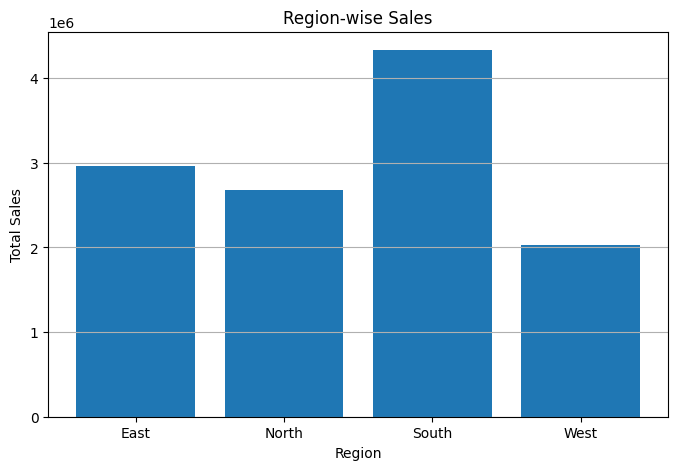

In [16]:
import matplotlib.pyplot as plt

region_sales = df.groupby("Region")["Sales"].sum()

plt.figure(figsize=(8,5))
plt.bar(region_sales.index, region_sales.values)

plt.title("Region-wise Sales")
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.grid(axis="y")

plt.show()

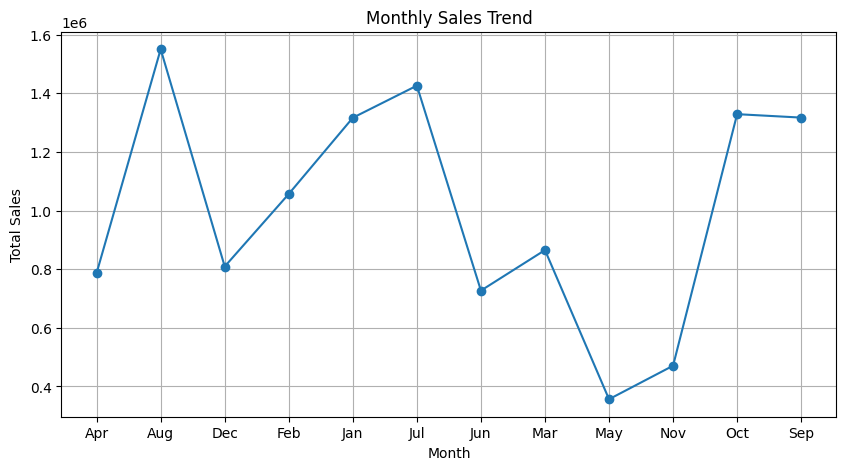

In [17]:
# Convert Order_Date to datetime
df["Order_Date"] = pd.to_datetime(df["Order_Date"])

# Create Month column
df["Month"] = df["Order_Date"].dt.strftime("%b")

monthly_sales = df.groupby("Month")["Sales"].sum()

plt.figure(figsize=(10,5))
plt.plot(monthly_sales.index, monthly_sales.values, marker="o")

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.grid()

plt.show()

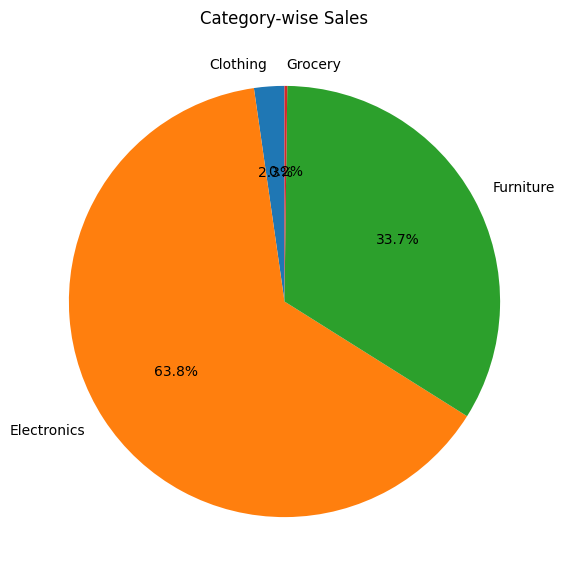

In [18]:
category_sales = df.groupby("Category")["Sales"].sum()

plt.figure(figsize=(7,7))
plt.pie(category_sales.values,
        labels=category_sales.index,
        autopct="%1.1f%%",
        startangle=90)

plt.title("Category-wise Sales")
plt.show()

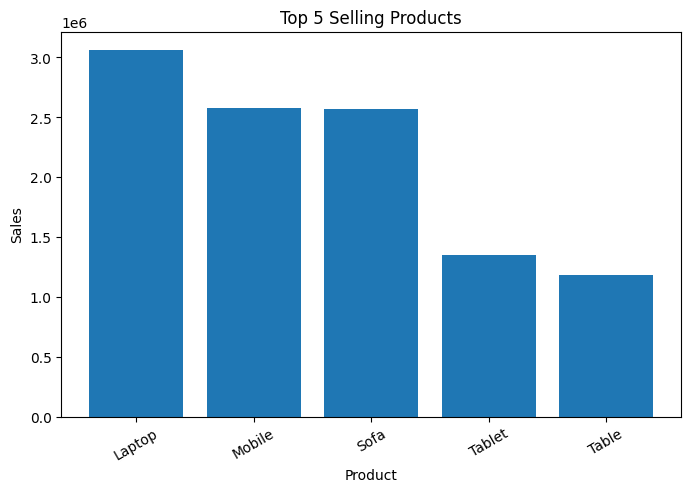

In [19]:
top_products = df.groupby("Product")["Sales"].sum().sort_values(ascending=False).head(5)

plt.figure(figsize=(8,5))
plt.bar(top_products.index, top_products.values)

plt.title("Top 5 Selling Products")
plt.xlabel("Product")
plt.ylabel("Sales")
plt.xticks(rotation=30)

plt.show()

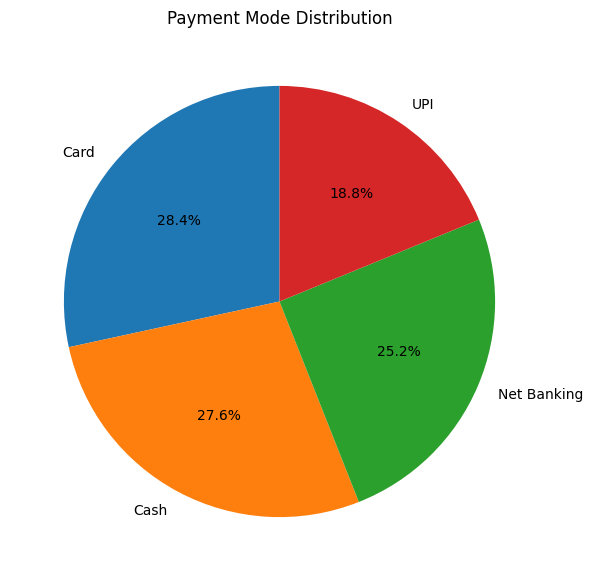

In [20]:
payment = df["Payment_Mode"].value_counts()

plt.figure(figsize=(7,7))
plt.pie(payment.values,
        labels=payment.index,
        autopct="%1.1f%%",
        startangle=90)

plt.title("Payment Mode Distribution")
plt.show()

In [21]:
average_order = df["Sales"].mean()
print("Average Order Value:", round(average_order,2))

Average Order Value: 48044.04


In [22]:
print(df.groupby("Product")["Profit"].sum().sort_values(ascending=False).head())

Product
Laptop    570620.45
Mobile    470816.36
Sofa      456464.26
Tablet    220888.89
Table     216986.34
Name: Profit, dtype: float64


In [23]:
print("Highest Sales Region :", df.groupby("Region")["Sales"].sum().idxmax())
print("Top Selling Product :", df.groupby("Product")["Sales"].sum().idxmax())
print("Most Used Payment Mode :", df["Payment_Mode"].value_counts().idxmax())

Highest Sales Region : South
Top Selling Product : Laptop
Most Used Payment Mode : Card
